In [9]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = fasterrcnn_resnet50_fpn(weights=None)  # Non carichiamo i pesi predefiniti
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)  # 2 classi: sfondo e arma

model_path = '../best_model_fasterrcnn_dropout.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()  # Imposta il modello in modalità valutazione

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [10]:
def apply_nms(boxes, scores, iou_threshold=0.5):
    # Applica NMS
    keep_indices = torchvision.ops.nms(boxes, scores, iou_threshold)
    
    # Riconverti in numpy
    return keep_indices.cpu().numpy()

In [11]:
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    image_tensor = transform(image)
    return image, image_tensor

In [12]:
def visualize_prediction(image, boxes, scores, labels, threshold=0.5):
    # Crea una copia dell'immagine per disegnare
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    
    # Filtra le predizioni in base alla soglia di confidenza
    filtered_boxes = []
    filtered_scores = []
    filtered_labels = []
    
    for box, score, label in zip(boxes, scores, labels):
        if score >= threshold:
            filtered_boxes.append(box)
            filtered_scores.append(score)
            filtered_labels.append(label)
    
    # Disegna i box e le etichette
    for box, score, label in zip(filtered_boxes, filtered_scores, filtered_labels):
        x1, y1, x2, y2 = box
        
        # Disegna il rettangolo
        draw.rectangle([(x1, y1), (x2, y2)], outline="red", width=3)
        
        # Aggiungi l'etichetta e il punteggio
        label_text = f"Pistola: {score:.2f}"
        draw.text((x1, y1-15), label_text, fill="red")
    
    # Mostra l'immagine
    plt.figure(figsize=(12, 8))
    plt.imshow(np.array(draw_image))
    plt.axis('off')
    plt.show()
    
    return draw_image

In [13]:
def detect_guns(image_path, confidence_threshold=0.5):
    # Carica e preprocessa l'immagine
    original_image, image_tensor = load_image(image_path)
    
    # Esegui l'inferenza
    with torch.no_grad():
        prediction = model([image_tensor.to(device)])
        
    
    # Estrai i risultati
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()
    
    keep_indices = apply_nms(torch.tensor(boxes), torch.tensor(scores), iou_threshold=0.2)
    
    boxes = boxes[keep_indices]
    scores = scores[keep_indices]
    labels = labels[keep_indices]
    # Visualizza i risultati
    result_image = visualize_prediction(original_image, boxes, scores, labels, confidence_threshold)
    
    return {
        'boxes': boxes,
        'scores': scores,
        'labels': labels,
        'result_image': result_image
    }

Esecuzione rilevamento armi su: ../Demo/demo_images\demo (1).jpg


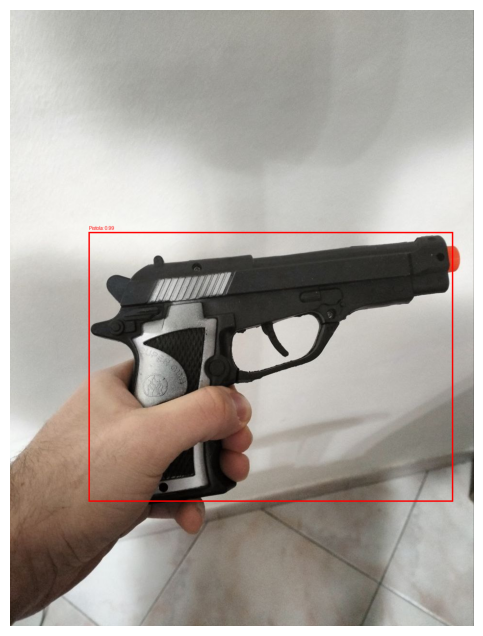

Esecuzione rilevamento armi su: ../Demo/demo_images\demo (2).jpg


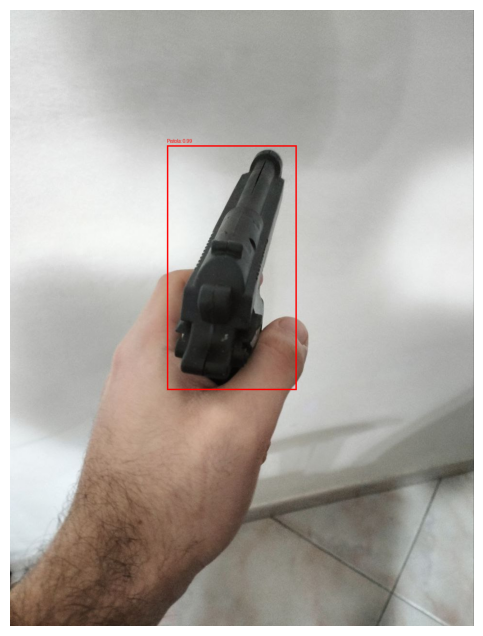

Esecuzione rilevamento armi su: ../Demo/demo_images\demo (3).jpg


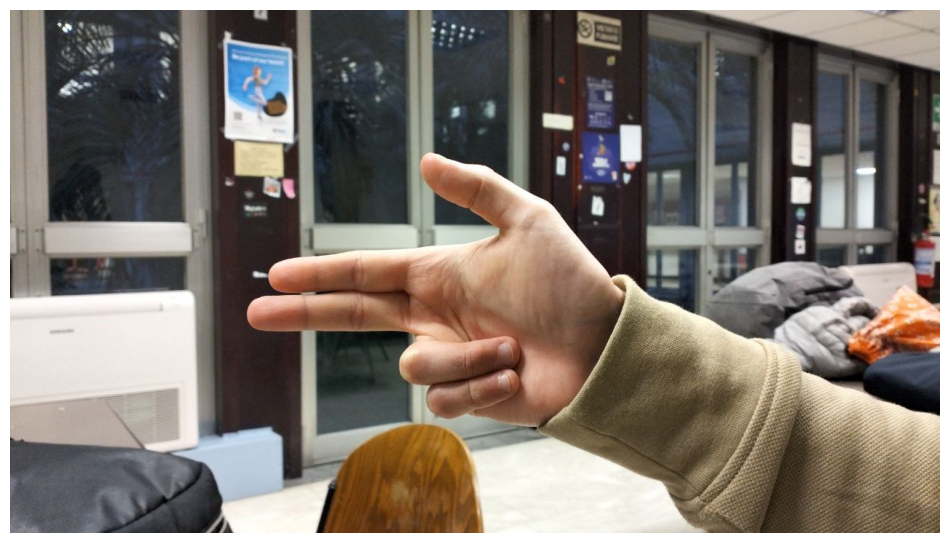

Esecuzione rilevamento armi su: ../Demo/demo_images\demo (4).jpg


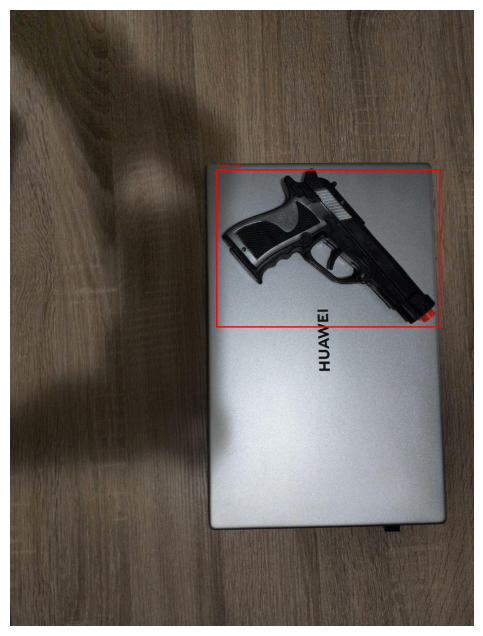

Armi rilevate: 3


In [14]:
if __name__ == "__main__":
    demo_images = os.listdir("../Demo/demo_images")
    demo_images = [os.path.join("../Demo/demo_images", image) for image in demo_images]
    guns_detected = 0
    
    for image_path in demo_images:
        print(f"Esecuzione rilevamento armi su: {image_path}")
        results = detect_guns(image_path, confidence_threshold=0.85)
        guns_detected += sum(1 for score in results['scores'] if score >= 0.85)
        
    print(f"Armi rilevate: {guns_detected}")
    
    # Opzionale: salva l'immagine risultante
    # results['result_image'].save("risultato_rilevamento.jpg")